# Set up and imports

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [100]:
los_df=pd.read_csv(r"/Users/mussabasif/hospital-los-prediction/hospital-los-prediction/data/LengthOfStay.csv")
los_df.head()


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [101]:
los_df.shape
# has 28 columns and 100,000 rows

(100000, 28)

In [102]:
los_df.columns
# reviewing all columns that are part of the dataset, to drop those that are not necessary. 

Index(['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma',
       'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor',
       'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo',
       'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro',
       'creatinine', 'bmi', 'pulse', 'respiration',
       'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay'],
      dtype='object')

In [103]:
# Checking for datatype for all columns
los_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

In [104]:
# reviewing statistically signifcant values of columns part of the dataset. 
los_df.describe().T

,count,mean,std,min,25%,50%,75%,max
eid,100000.0,50000.500000,28867.657797,1.000000,25000.750000,50000.500000,75000.250000,100000.000000
dialysisrenalendstage,100000.0,0.036420,0.187334,0.000000,0.000000,0.000000,0.000000,1.000000
asthma,100000.0,0.035270,0.184462,0.000000,0.000000,0.000000,0.000000,1.000000
irondef,100000.0,0.094940,0.293134,0.000000,0.000000,0.000000,0.000000,1.000000
pneum,100000.0,0.039450,0.194664,0.000000,0.000000,0.000000,0.000000,1.000000
substancedependence,100000.0,0.063060,0.243072,0.000000,0.000000,0.000000,0.000000,1.000000
psychologicaldisordermajor,100000.0,0.239040,0.426499,0.000000,0.000000,0.000000,0.000000,1.000000
depress,100000.0,0.051660,0.221341,0.000000,0.000000,0.000000,0.000000,1.000000
psychother,100000.0,0.049390,0.216682,0.000000,0.000000,0.000000,0.000000,1.000000
fibrosisandother,100000.0,0.004790,0.069044,0.000000,0.000000,0.000000,0.000000,1.000000


In [105]:
# ensuring if the dataset has any duplicate rows
los_df.duplicated().sum()


np.int64(0)

# Distribution of the target variable

## Length of stay count plot

<Axes: xlabel='lengthofstay'>

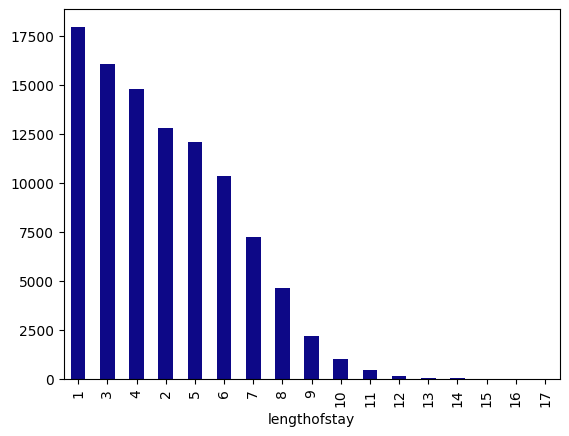

In [106]:
fig, ax= plt.subplots()
los_count=los_df['lengthofstay'].value_counts()
los_count.plot(kind='bar', colormap='plasma')

## Distribution of key predictors

### bmi

Text(0.5, 0, 'BMI score')

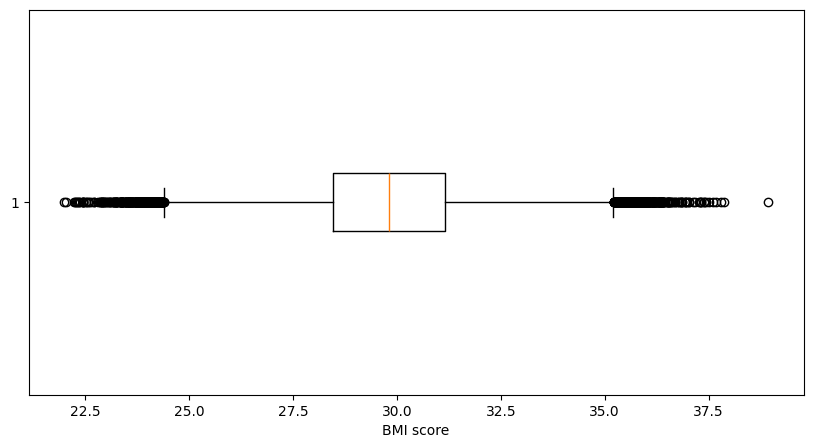

In [107]:
fig=plt.figure(figsize=(10, 5))
bmi_value=los_df['bmi']
plt.boxplot(bmi_value,vert=False )
plt.xlabel('BMI score')


### glucose

Text(0.5, 0, 'Glucose values')

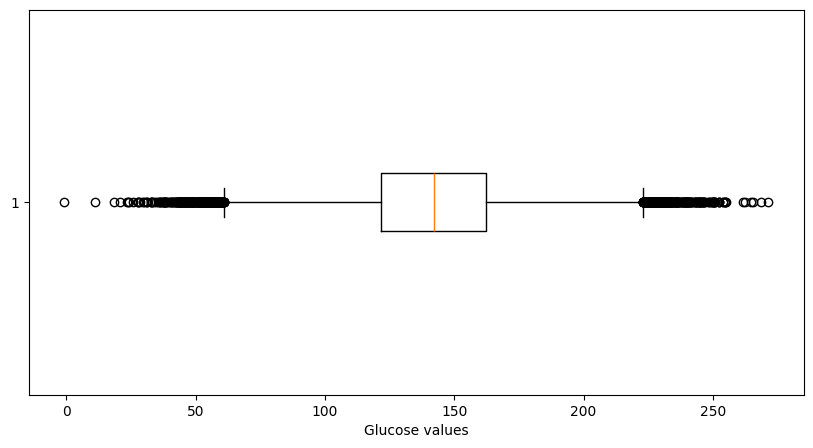

In [108]:
fig=plt.figure(figsize=(10, 5))
glucose_values=los_df['glucose']
plt.boxplot(glucose_values, vert=False)
plt.xlabel('Glucose values')


### Pulse

Text(0.5, 0, 'pulse values')

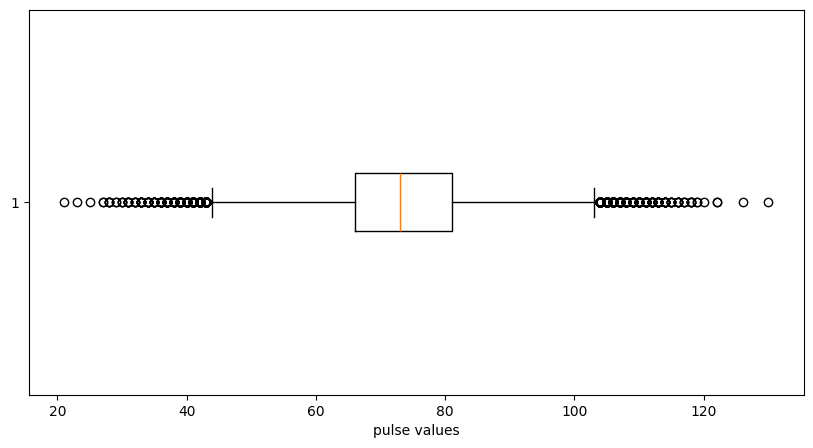

In [109]:
fig=plt.figure(figsize=(10, 5))
pulse_values=los_df['pulse']
plt.boxplot(pulse_values, vert=False)
plt.xlabel('pulse values')

0    0
4    1
Name: psychologicaldisordermajor, dtype: int64